# (노트) Barplot, 해들리위컴의 그래프레이어 문법

- toc:true
- branch: master
- badges: true
- comments: true
- author: 최규빈
- hide: true
- categories: [시각화]

### import 

In [425]:
import pandas as pd 
import numpy as np
from plotnine import * 
import matplotlib.pyplot as plt

### Barplot

#### 기본사용법 (stat)

In [426]:
g=['A']*100+['B']*200
y=list(np.random.randn(100)*2+2)+list(np.random.randn(200)+3)
df=pd.DataFrame({'g':g,'y':y})
df

,g,y
0,A,3.223406
1,A,0.380485
2,A,0.553099
3,A,7.326087
4,A,1.714722
...,...,...
295,B,0.793927
296,B,2.290326
297,B,3.433332
298,B,1.571732


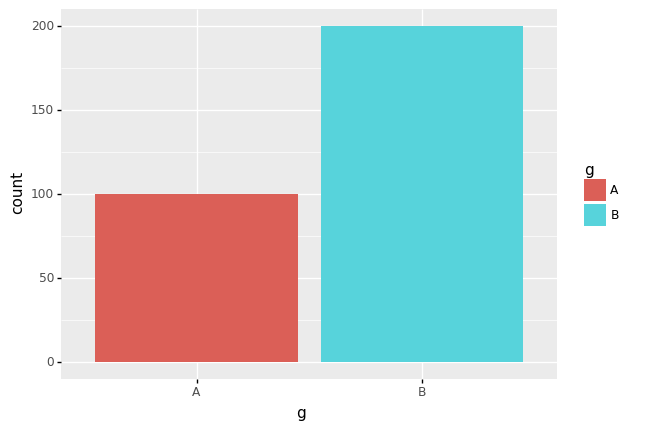

<ggplot: (8742233496631)>

In [427]:
ggplot(df)+geom_bar(aes(x='g',fill='g')) ## 디폴트로 카운트를 수행해줌

`-` 이것은 아래의 코드와 같다. 

In [428]:
df.groupby('g').count().reset_index()

,g,y
0,A,100
1,B,200


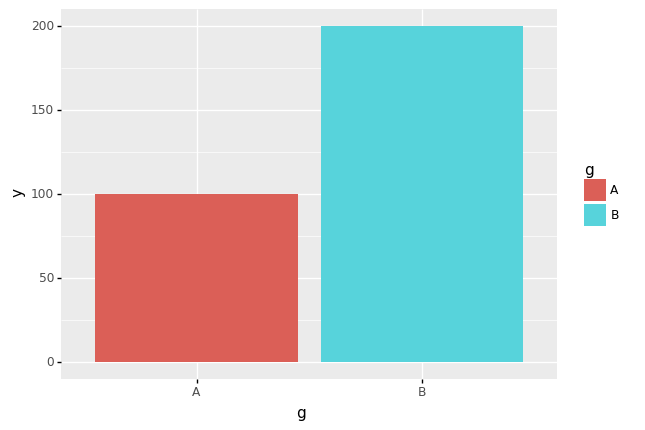

<ggplot: (8742233162379)>

In [429]:
ggplot(df.groupby('g').count().reset_index())+geom_bar(aes(x='g',y='y',fill='g'),stat='identity')

`-` barplot은 기본적으로 groupby+count() 가 내장되어있다. 따라서 아래의 코드를 엄밀하게 쓰면 

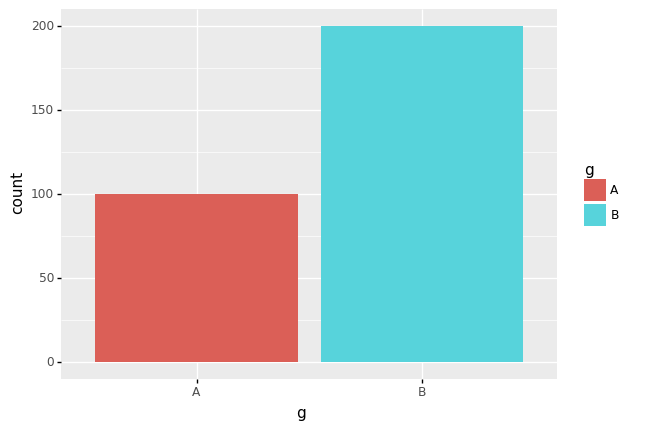

<ggplot: (8742244336984)>

In [432]:
ggplot(df)+geom_bar(aes(x='g',fill='g')) 

아래와 같다. 

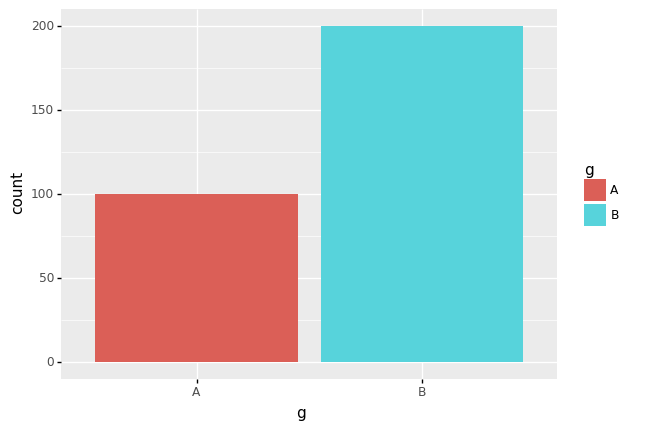

<ggplot: (8742231849780)>

In [434]:
ggplot(df)+geom_bar(aes(x='g',fill='g'),stat='count') 

`-` 이것은 때때로 불편하다. (요건 제 생각이에요) 
- 데이터프레임 변환은 판다스를 이용하는게 더 쉽고 자유롭다. 

#### barplot이 불편한점1

In [436]:
tb=df.groupby('g').count().reset_index()
tb

,g,y
0,A,100
1,B,200


`-` 그냥 x='g', y='y'를 맵핑해서 그리면되지 않나? 

<BarContainer object of 2 artists>

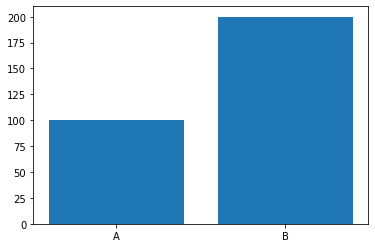

In [437]:
plt.bar(tb.g,tb.y)

<AxesSubplot:xlabel='g'>

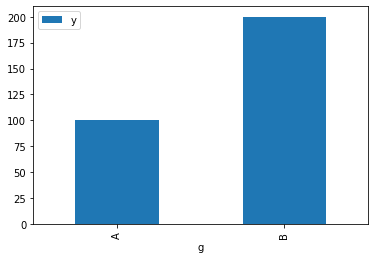

In [438]:
tb.plot(kind='bar',x='g',y='y')

`-` 그런데 ggplot을 쓰려고하면?

In [439]:
ggplot(df.groupby('g').count().reset_index())+geom_bar(aes(x='g',y='y',fill='g'))

PlotnineError: 'stat_count() must not be used with a y aesthetic'

- 불편해요..

#### barplot이 불편한점2

`-` group_by를 자동으로 해주므로 익숙해지면 더 편하지 않을까? $\to$ group_by()를 그냥 하는게 편해요

In [440]:
df.groupby('g').agg({'y':[np.mean,np.median,np.std,lambda x: np.max(x)-np.min(x)]})

y                               
       mean    median       std <lambda_0>
g                                         
A  2.045670  1.874733  2.027999   9.910684
B  3.126434  3.169176  0.905798   5.006031

In [441]:
df.groupby('g').agg({'y':[np.mean,np.median,np.std,lambda x: np.max(x)-np.min(x)]}).rename(columns={'<lambda_0>':'range'})

y                              
       mean    median       std     range
g                                        
A  2.045670  1.874733  2.027999  9.910684
B  3.126434  3.169176  0.905798  5.006031

In [442]:
df.groupby('g').agg({'y':[np.mean,np.median,np.std,lambda x: np.max(x)-np.min(x)]}).rename(columns={'<lambda_0>':'range'}).unstack()

           g
y  mean    A    2.045670
           B    3.126434
   median  A    1.874733
           B    3.169176
   std     A    2.027999
           B    0.905798
   range   A    9.910684
           B    5.006031
dtype: float64

In [443]:
df.groupby('g').agg({'y':[np.mean,np.median,np.std,lambda x: np.max(x)-np.min(x)]}).rename(columns={'<lambda_0>':'range'}).unstack().reset_index()

,level_0,level_1,g,0
0,y,mean,A,2.045670
1,y,mean,B,3.126434
2,y,median,A,1.874733
3,y,median,B,3.169176
4,y,std,A,2.027999
5,y,std,B,0.905798
6,y,range,A,9.910684
7,y,range,B,5.006031


In [444]:
df.groupby('g').agg({'y':[np.mean,np.median,np.std,lambda x: np.max(x)-np.min(x)]}).rename(columns={'<lambda_0>':'range'}).unstack().reset_index().rename(columns={0:'value'})

,level_0,level_1,g,value
0,y,mean,A,2.045670
1,y,mean,B,3.126434
2,y,median,A,1.874733
3,y,median,B,3.169176
4,y,std,A,2.027999
5,y,std,B,0.905798
6,y,range,A,9.910684
7,y,range,B,5.006031


In [445]:
fig=ggplot(df.groupby('g').agg({'y':[np.mean,np.median,np.std,lambda x: np.max(x)-np.min(x)]}).rename(columns={'<lambda_0>':'range'}).unstack().reset_index().rename(columns={0:'value'}))

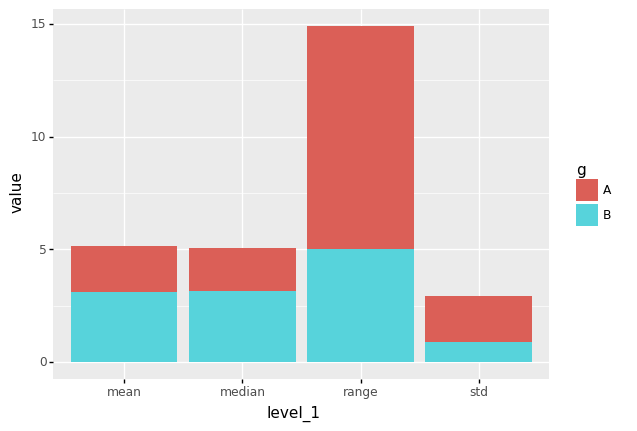

<ggplot: (8742231855601)>

In [446]:
bar1=geom_bar(aes(x='level_1',y='value',fill='g'),stat='identity')
fig+bar1

- 쌓아져서 보이는것이 불편해요.. 

#### position 조정

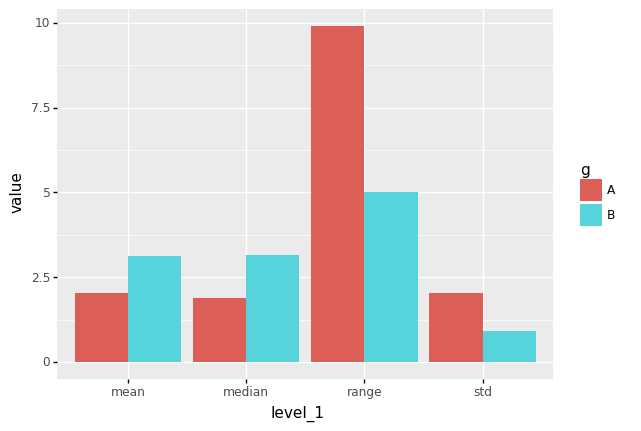

<ggplot: (8742232176752)>

In [447]:
fig+geom_bar(aes(x='level_1',y='value',fill='g'),stat='identity',position='dodge')

#### coord_filp() 

`-` 때때로 아래와 같이 보는것이 더 좋을 경우도 있음. 

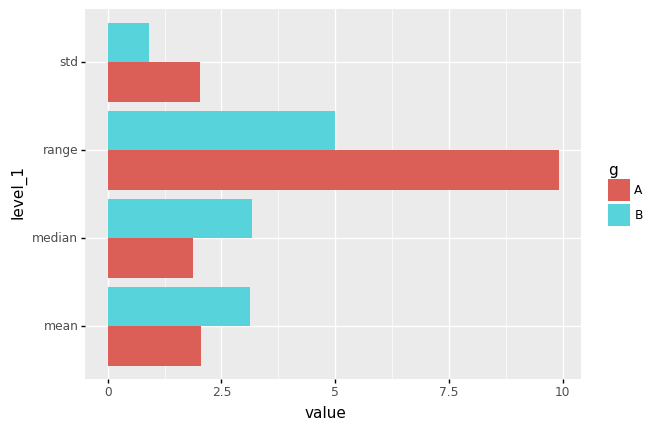

<ggplot: (8742231262251)>

In [449]:
fig+geom_bar(aes(x='level_1',y='value',fill='g'),stat='identity',position='dodge')+coord_flip()

#### facet_wrap() 

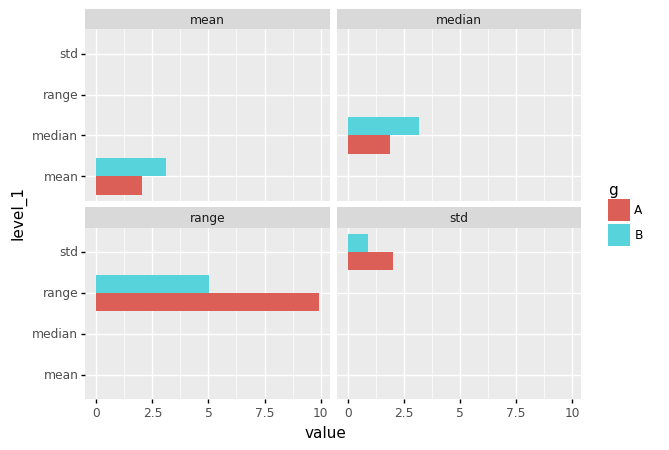

<ggplot: (8742231040175)>

In [463]:
fig+geom_bar(aes(x='level_1',y='value',fill='g'),stat='identity',position='dodge')+coord_flip()+facet_wrap('level_1')

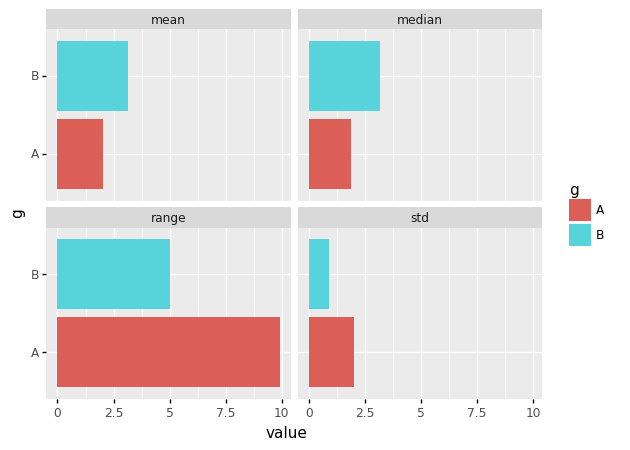

<ggplot: (8742230801146)>

In [465]:
fig+geom_bar(aes(x='g',y='value',fill='g'),stat='identity',position='dodge')+coord_flip()+facet_wrap('level_1')

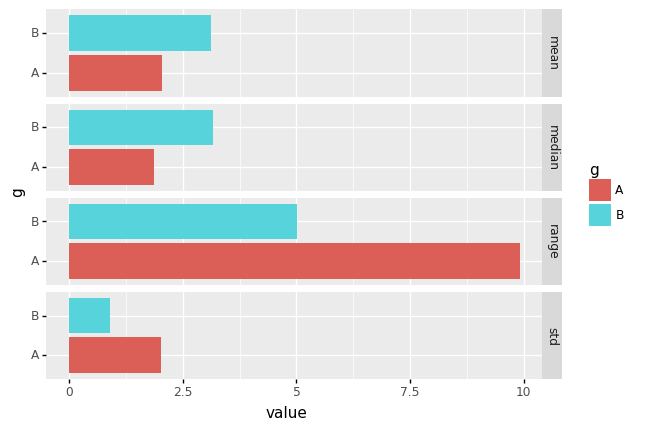

<ggplot: (8742230733593)>

In [467]:
fig+geom_bar(aes(x='g',y='value',fill='g'),stat='identity',position='dodge')+coord_flip()+facet_grid('level_1~')

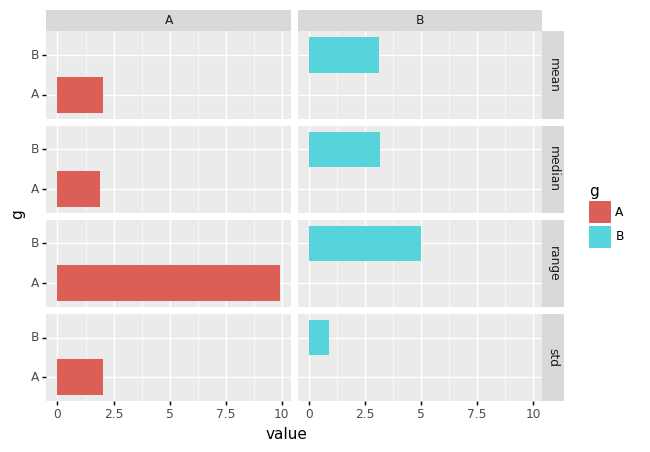

<ggplot: (8742231320218)>

In [469]:
fig+geom_bar(aes(x='g',y='value',fill='g'),stat='identity',position='dodge')+coord_flip()+facet_grid('level_1~g')

### 해들리위컴의 그래프레이어

`-` 데이터셋 + 맵핑 + 지옴 + 포지션 + 스탯 + 축 + 면분할

- 데이터셋: 판다스
- 맵핑: x축, y축, 색깔, 크기, 투명도
- 지옴: 포인트지옴, 바지옴, 라인지옴, 스무스지옴 
- 포지션: jitter, dodge, indentity 
- 스탯: identity, count 
- 축: coord_flip()
- 패싯: facet_wrap(), facet_grid() 

### 예제: 심슨의 역설

In [248]:
DEP=(['A1']*2+['A2']*2+['B1']*2+['B2']*2)*2
GEN=['M']*8+['F']*8
STATE=['PASS','FAIL']*8
COUNT=[1,9,2,8,80,20,85,15,5,5,5,5,9,1,9,1]

In [249]:
df=pd.DataFrame({'DEP':DEP,'STATE':STATE,'GEN':GEN,'COUNT':COUNT})

In [250]:
df

,DEP,STATE,GEN,COUNT
0,A1,PASS,M,1
1,A1,FAIL,M,9
2,A2,PASS,M,2
3,A2,FAIL,M,8
4,B1,PASS,M,80
5,B1,FAIL,M,20
6,B2,PASS,M,85
7,B2,FAIL,M,15
8,A1,PASS,F,5
9,A1,FAIL,F,5


#### 시각화1: 전체합격률을 barplot으로 시각화하라.

`-` 전체합격률을 barplot으로 시각화

In [251]:
df.groupby(['GEN','STATE']).agg({'COUNT':sum})

COUNT
GEN STATE       
F   FAIL      12
    PASS      28
M   FAIL      52
    PASS     168

In [252]:
df.groupby(['GEN','STATE']).agg({'COUNT':sum}).reset_index()

,GEN,STATE,COUNT
0,F,FAIL,12
1,F,PASS,28
2,M,FAIL,52
3,M,PASS,168


In [253]:
df.groupby('GEN').agg({'COUNT':np.sum}).reset_index().rename(columns={'COUNT':'SUM'})

,GEN,SUM
0,F,40
1,M,220


In [254]:
_df1=df.groupby(['GEN','STATE']).agg({'COUNT':sum}).reset_index()
_df2=df.groupby('GEN').agg({'COUNT':np.sum}).reset_index().rename(columns={'COUNT':'SUM'})

In [255]:
display(_df1)
display(_df2)

,GEN,STATE,COUNT
0,F,FAIL,12
1,F,PASS,28
2,M,FAIL,52
3,M,PASS,168


,GEN,SUM
0,F,40
1,M,220


In [256]:
tb=pd.merge(_df1,_df2)
tb

,GEN,STATE,COUNT,SUM
0,F,FAIL,12,40
1,F,PASS,28,40
2,M,FAIL,52,220
3,M,PASS,168,220


In [257]:
tb['Prop']=_df.COUNT/_df.SUM
tb

,GEN,STATE,COUNT,SUM,Prop
0,F,FAIL,12,40,0.300000
1,F,PASS,28,40,0.700000
2,M,FAIL,52,220,0.236364
3,M,PASS,168,220,0.763636


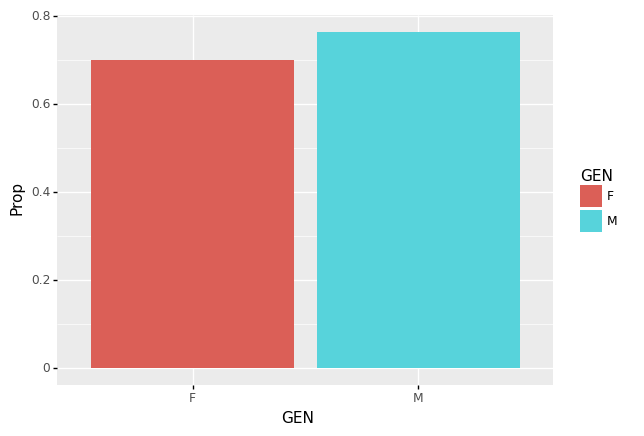

<ggplot: (8742233179908)>

In [258]:
ggplot(tb.query('STATE=="PASS"'))+geom_bar(aes(x='GEN',y='Prop',fill='GEN'),position='dodge',stat='identity')

`-` 남자의 합격률이 더 높다 $\to$ 성차별이 있어보인다(?)

#### 시각화2: 학과별비교

`-` 학과별로 비교하자. 

In [259]:
df

,DEP,STATE,GEN,COUNT
0,A1,PASS,M,1
1,A1,FAIL,M,9
2,A2,PASS,M,2
3,A2,FAIL,M,8
4,B1,PASS,M,80
5,B1,FAIL,M,20
6,B2,PASS,M,85
7,B2,FAIL,M,15
8,A1,PASS,F,5
9,A1,FAIL,F,5


In [260]:
df.groupby(['GEN','DEP','STATE']).agg({'COUNT':sum})

COUNT
GEN DEP STATE       
F   A1  FAIL       5
        PASS       5
    A2  FAIL       5
        PASS       5
    B1  FAIL       1
        PASS       9
    B2  FAIL       1
        PASS       9
M   A1  FAIL       9
        PASS       1
    A2  FAIL       8
        PASS       2
    B1  FAIL      20
        PASS      80
    B2  FAIL      15
        PASS      85

In [261]:
df.groupby(['GEN','STATE','DEP']).agg({'COUNT':sum}).reset_index()

,GEN,STATE,DEP,COUNT
0,F,FAIL,A1,5
1,F,FAIL,A2,5
2,F,FAIL,B1,1
3,F,FAIL,B2,1
4,F,PASS,A1,5
5,F,PASS,A2,5
6,F,PASS,B1,9
7,F,PASS,B2,9
8,M,FAIL,A1,9
9,M,FAIL,A2,8


In [262]:
df.groupby(['GEN','DEP']).agg({'COUNT':sum}).reset_index().rename(columns={'COUNT':'SUM'})

,GEN,DEP,SUM
0,F,A1,10
1,F,A2,10
2,F,B1,10
3,F,B2,10
4,M,A1,10
5,M,A2,10
6,M,B1,100
7,M,B2,100


In [263]:
tb=df.groupby(['GEN','STATE','DEP']).agg({'COUNT':sum}).reset_index().merge(df.groupby(['GEN','DEP']).agg({'COUNT':sum}).reset_index().rename(columns={'COUNT':'SUM'}))
tb

,GEN,STATE,DEP,COUNT,SUM
0,F,FAIL,A1,5,10
1,F,PASS,A1,5,10
2,F,FAIL,A2,5,10
3,F,PASS,A2,5,10
4,F,FAIL,B1,1,10
5,F,PASS,B1,9,10
6,F,FAIL,B2,1,10
7,F,PASS,B2,9,10
8,M,FAIL,A1,9,10
9,M,PASS,A1,1,10


In [264]:
tb['Prop']=tb.COUNT/tb.SUM
tb

,GEN,STATE,DEP,COUNT,SUM,Prop
0,F,FAIL,A1,5,10,0.50
1,F,PASS,A1,5,10,0.50
2,F,FAIL,A2,5,10,0.50
3,F,PASS,A2,5,10,0.50
4,F,FAIL,B1,1,10,0.10
5,F,PASS,B1,9,10,0.90
6,F,FAIL,B2,1,10,0.10
7,F,PASS,B2,9,10,0.90
8,M,FAIL,A1,9,10,0.90
9,M,PASS,A1,1,10,0.10


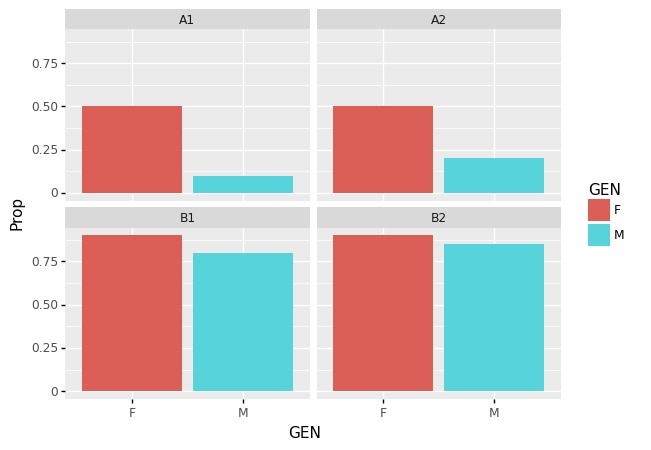

<ggplot: (8742233183001)>

In [265]:
ggplot(tb.query('STATE=="PASS"'))+geom_bar(aes(x='GEN',y='Prop',fill='GEN'),position='dodge',stat='identity')+facet_wrap("DEP")

`-` 모든학과에서 여성의 합격률이 더 높다. 